# Day 18 — 布林带（Bollinger Bands）+ 量价关系

**目标**：掌握布林带的计算逻辑和实战用法，理解成交量如何验证价格信号

- 🌅 上午：布林带三线手算 + 股价轨道图
- ☀️ 下午：%B 指标、带宽、布林带挤压
- 🌙 晚上：量价关系 + BB 信号验证

In [1]:
# ===== 基础设置 =====
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import font_manager

font_manager.fontManager.addfont('/System/Library/Fonts/Hiragino Sans GB.ttc')
plt.rcParams['font.family'] = 'Hiragino Sans GB'
plt.rcParams['axes.unicode_minus'] = False

print('环境就绪')

环境就绪


## 🌅 上午：布林带原理与手算

布林带（Bollinger Bands）由 John Bollinger 在 1980 年代发明，是全世界最常用的波动率指标。

### 三根线的含义

$$
\text{中轨 (Middle)} = \text{SMA}(N) = \frac{1}{N}\sum_{i=1}^{N} P_i
$$
$$
\text{上轨 (Upper)} = \text{Middle} + k \times \sigma
$$
$$
\text{下轨 (Lower)} = \text{Middle} - k \times \sigma
$$

- **中轨** = N 日简单移动平均（默认 20 日）
- **上轨/下轨** = 中轨 ± k 倍标准差（默认 k=2）
- **σ（标准差）** = 过去 N 天的价格波动程度

> 直觉：中轨是「价格的均值」，上下轨是「均值 ± 两倍波动范围」。价格 95% 的时间都在轨道内运行。碰到上轨 = 涨太多了，碰到下轨 = 跌太多了。

In [2]:
# 加载数据
df = pd.read_csv('../data/茅台.csv')
df['日期'] = pd.to_datetime(df['日期'])
df = df.set_index('日期').sort_index()

print(f'数据: {len(df)} 行, {df.index[0].date()} ~ {df.index[-1].date()}')

数据: 250 行, 2025-07-01 ~ 2026-07-10


In [3]:
# ===== 手算布林带（最近20天） =====

N = 20  # 布林带标准周期
k = 2   # 标准差倍数

# 取最近 N 天的收盘价
last_N = df['收盘'].iloc[-N:]
print(f'最近 {N} 天收盘价:')
print(last_N.tail(5))

# 手算中轨
middle = last_N.mean()
print(f'\n中轨(SMA-20) = {middle:.2f}')

# 手算标准差（ddof=1 是样本标准差，Pandas 默认 ddof=0 是总体标准差，我们保持一致用 ddof=0）
std = last_N.std(ddof=0)  # Pandas rolling.std() 默认 ddof=0
print(f'标准差 = {std:.2f}')

# 上轨和下轨
upper = middle + k * std
lower = middle - k * std
print(f'\n上轨 = {middle:.2f} + {k} × {std:.2f} = {upper:.2f}')
print(f'下轨 = {middle:.2f} - {k} × {std:.2f} = {lower:.2f}')

print(f'\n当前收盘价 = {df["收盘"].iloc[-1]:.2f}')
print(f'布林带宽度 = {upper - lower:.2f} 元')
print(f'价格位置 = 距上轨 {upper - df["收盘"].iloc[-1]:.2f}，距下轨 {df["收盘"].iloc[-1] - lower:.2f}')

最近 20 天收盘价:
日期
2026-07-06    1206.91
2026-07-07    1188.80
2026-07-08    1199.30
2026-07-09    1182.19
2026-07-10    1204.98
Name: 收盘, dtype: float64

中轨(SMA-20) = 1201.34
标准差 = 22.00

上轨 = 1201.34 + 2 × 22.00 = 1245.35
下轨 = 1201.34 - 2 × 22.00 = 1157.34

当前收盘价 = 1204.98
布林带宽度 = 88.01 元
价格位置 = 距上轨 40.37，距下轨 47.64


In [4]:
# ===== 验证：手算 vs Pandas =====

df['BB_Mid'] = df['收盘'].rolling(N).mean()
df['BB_Std'] = df['收盘'].rolling(N).std(ddof=0)
df['BB_Up'] = df['BB_Mid'] + k * df['BB_Std']
df['BB_Lo'] = df['BB_Mid'] - k * df['BB_Std']

# 对比最后一天
last = df.iloc[-1]
print('最后一天 手算 vs Pandas:')
print(f'  中轨: {middle:.2f} vs {last["BB_Mid"]:.2f}')
print(f'  上轨: {upper:.2f} vs {last["BB_Up"]:.2f}')
print(f'  下轨: {lower:.2f} vs {last["BB_Lo"]:.2f}')
print('\n完全一致！Pandas rolling().std() 就是手算的自动化。')

最后一天 手算 vs Pandas:
  中轨: 1201.34 vs 1201.34
  上轨: 1245.35 vs 1245.35
  下轨: 1157.34 vs 1157.34

完全一致！Pandas rolling().std() 就是手算的自动化。


findfont: Failed to find font weight normal, now using 300.
findfont: Failed to find font weight bold, now using 600.
findfont: Failed to find font weight normal, now using 300.


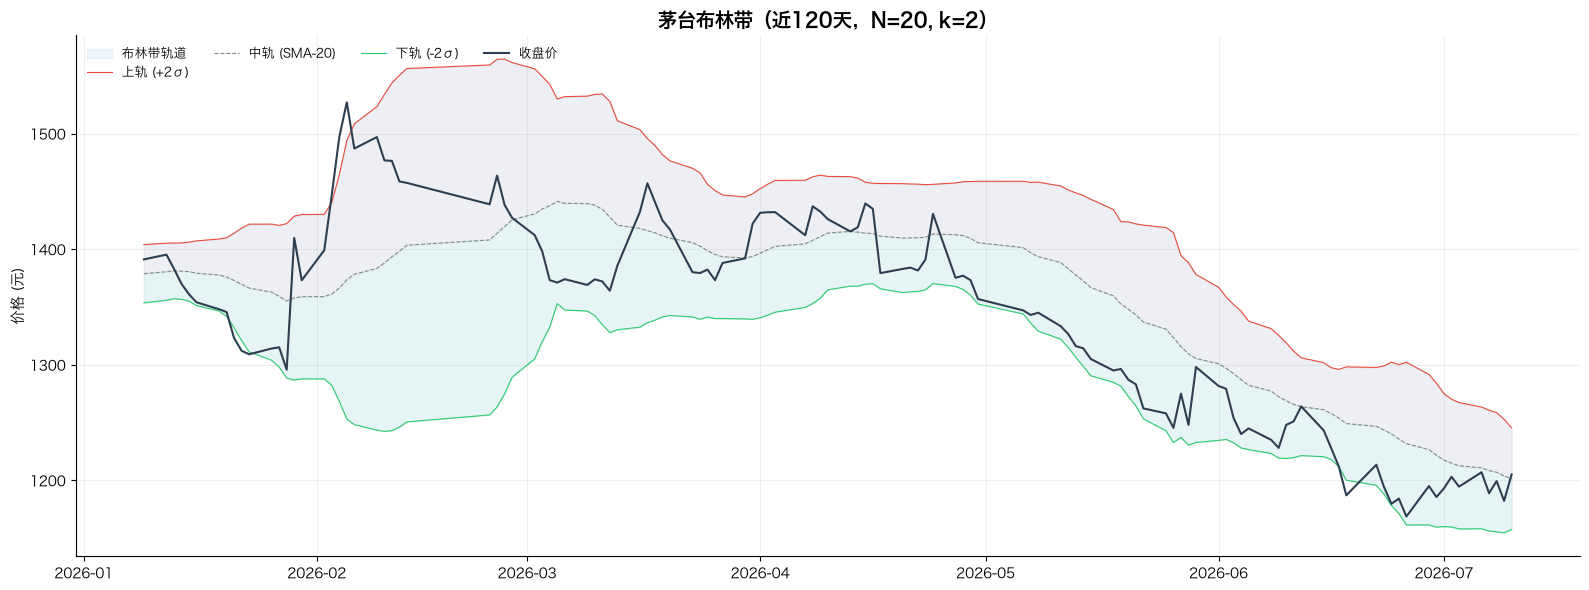

In [5]:
# ===== 布林带轨道图 =====

d = df.iloc[-120:]

fig, ax = plt.subplots(figsize=(16, 6))

# 填充轨道区域
ax.fill_between(d.index, d['BB_Up'], d['BB_Lo'], alpha=0.08, color='#3498db', label='布林带轨道')
ax.fill_between(d.index, d['BB_Mid'], d['BB_Up'], alpha=0.04, color='#e74c3c')
ax.fill_between(d.index, d['BB_Lo'], d['BB_Mid'], alpha=0.04, color='#2ecc71')

# 三根线
ax.plot(d.index, d['BB_Up'], color='#e74c3c', lw=0.8, label='上轨 (+2σ)')
ax.plot(d.index, d['BB_Mid'], color='#7f8c8d', lw=0.8, ls='--', label='中轨 (SMA-20)')
ax.plot(d.index, d['BB_Lo'], color='#2ecc71', lw=0.8, label='下轨 (-2σ)')

# 价格线
ax.plot(d.index, d['收盘'], color='#2c3e50', lw=1.5, label='收盘价')

ax.set_title('茅台布林带（近120天，N=20, k=2）', fontsize=14, fontweight='bold')
ax.legend(ncol=4, frameon=False, fontsize=9, loc='upper left')
ax.set_ylabel('价格 (元)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

### 布林带的四个核心规律

1. **价格回归中轨**：价格碰到上轨后有回落倾向，碰到下轨后有反弹倾向
2. **轨道收窄 = 爆发前兆**（squeeze）：波动率降到极低时，即将出现大行情
3. **价格沿轨道行走**：强势上涨时价格贴着上轨走，不是碰到就卖
4. **轨道扩张 = 趋势确认**：轨道向外张开，说明趋势在加速

> 最大的坑：碰到上轨就卖？大错。牛市中股价可以贴着上轨涨好几个月。布林带不是"碰线反转"指标，而是"波动率框架"。

## ☀️ 下午：布林带进阶指标

### %B — 价格在轨道中的位置

$$
\%B = \frac{P - \text{Lower}}{\text{Upper} - \text{Lower}}
$$

- %B = 1.0 → 价格贴着上轨
- %B = 0.5 → 价格在中轨
- %B = 0.0 → 价格贴着下轨
- %B > 1.0 → 价格突破上轨（超强）
- %B < 0.0 → 价格跌破下轨（超弱）

### 带宽（Bandwidth）— 波动率指标

$$
\text{Bandwidth} = \frac{\text{Upper} - \text{Lower}}{\text{Middle}}
$$

- 带宽大 = 波动率高 = 趋势行情
- 带宽小 = 波动率低 = 盘整行情（squeeze）

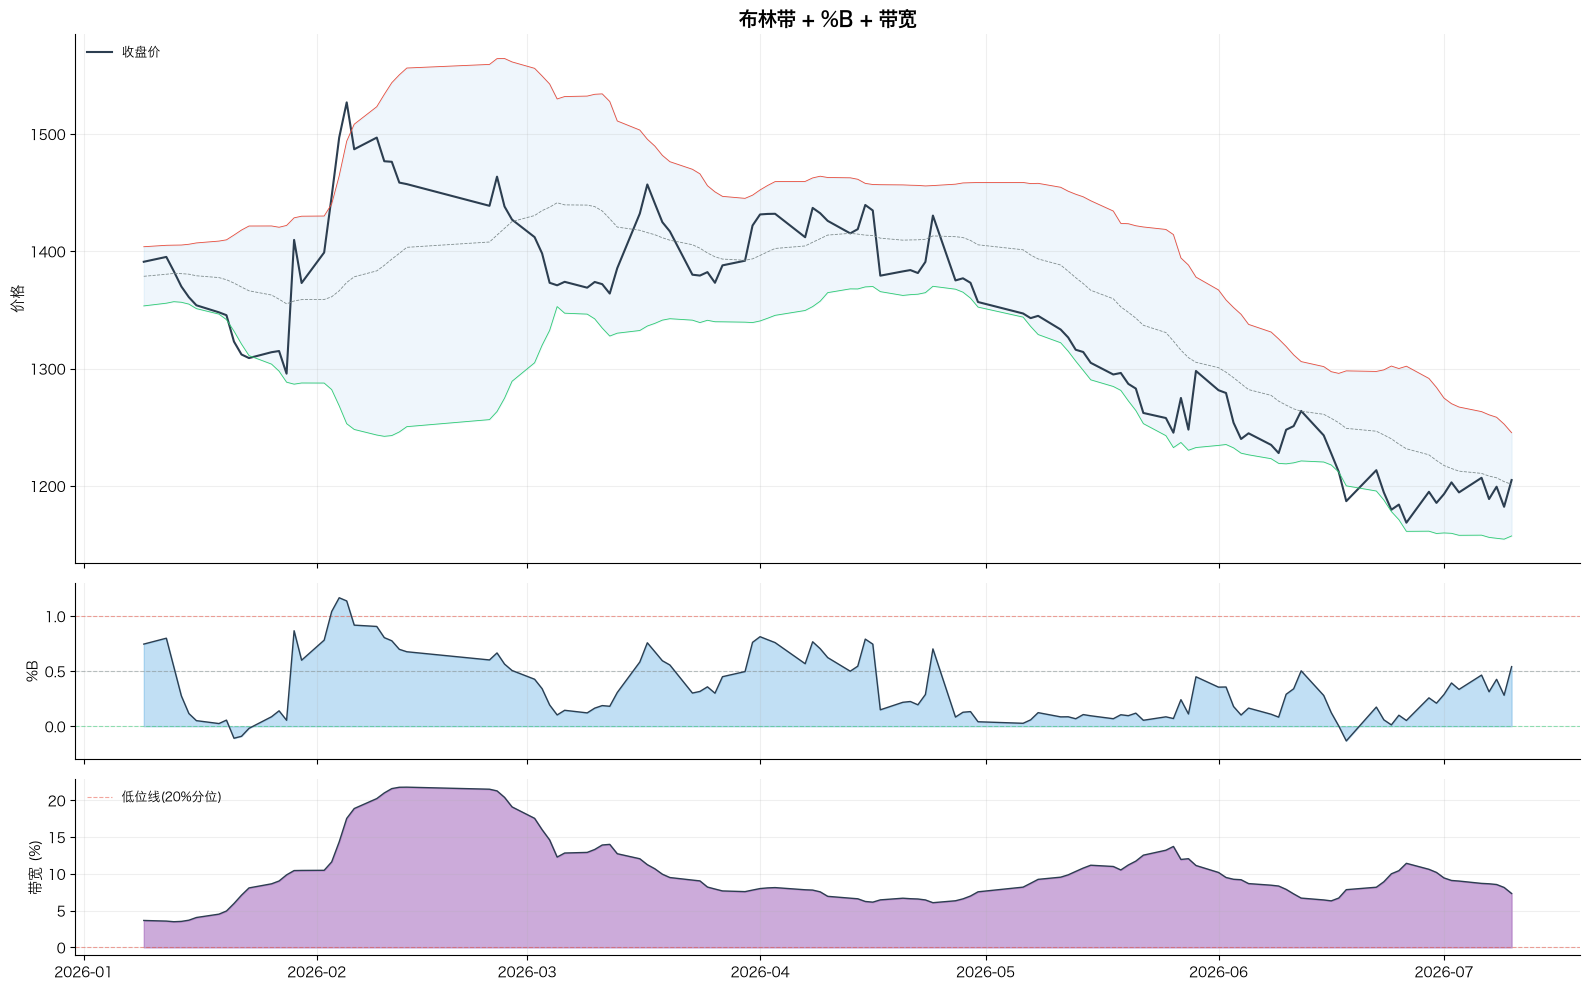

In [6]:
# ===== %B 和带宽 =====

df['BB_%B'] = (df['收盘'] - df['BB_Lo']) / (df['BB_Up'] - df['BB_Lo'])
df['BB_BW'] = (df['BB_Up'] - df['BB_Lo']) / df['BB_Mid']

# 近120天
d = df.iloc[-120:]

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 10),
                                     gridspec_kw={'height_ratios': [3, 1, 1]}, sharex=True)

# 图1: 价格 + 布林带
ax1.fill_between(d.index, d['BB_Up'], d['BB_Lo'], alpha=0.08, color='#3498db')
ax1.plot(d.index, d['收盘'], color='#2c3e50', lw=1.5, label='收盘价')
ax1.plot(d.index, d['BB_Up'], color='#e74c3c', lw=0.6)
ax1.plot(d.index, d['BB_Mid'], color='#7f8c8d', lw=0.6, ls='--')
ax1.plot(d.index, d['BB_Lo'], color='#2ecc71', lw=0.6)
ax1.set_title('布林带 + %B + 带宽', fontsize=14, fontweight='bold')
ax1.set_ylabel('价格')
ax1.legend(loc='upper left', frameon=False, fontsize=9)

# 图2: %B 指标
ax2.fill_between(d.index, 0, d['BB_%B'], alpha=0.3, color='#3498db')
ax2.axhline(1.0, color='#e74c3c', lw=0.8, ls='--', alpha=0.5)
ax2.axhline(0.5, color='#7f8c8d', lw=0.8, ls='--', alpha=0.5)
ax2.axhline(0.0, color='#2ecc71', lw=0.8, ls='--', alpha=0.5)
ax2.plot(d.index, d['BB_%B'], color='#2c3e50', lw=1)
ax2.set_ylabel('%B')
ax2.set_ylim(-0.3, 1.3)

# 图3: 带宽
ax3.fill_between(d.index, 0, d['BB_BW']*100, alpha=0.5, color='#9b59b6')
ax3.axhline(d['BB_BW'].iloc[-120:].quantile(0.2), color='#e74c3c', lw=0.8, ls='--', alpha=0.5, label='低位线(20%分位)')
ax3.plot(d.index, d['BB_BW']*100, color='#2c3e50', lw=1)
ax3.set_ylabel('带宽 (%)')
ax3.legend(loc='upper left', frameon=False, fontsize=9)

for ax in [ax1, ax2, ax3]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

In [7]:
# ===== 布林带挤压（Squeeze）检测 =====

# 挤压：带宽降到近一年最低的 20% 以下
squeeze_threshold = df['BB_BW'].rolling(250).quantile(0.2, interpolation='lower')
# ponytail: 用整个历史的分位替代 rolling(250).quantile，简单就够
squeeze_threshold = df['BB_BW'].quantile(0.2)
df['挤压'] = df['BB_BW'] < squeeze_threshold

print(f'带宽当前值: {df["BB_BW"].iloc[-1]*100:.1f}%')
print(f'挤压阈值(20%分位): {squeeze_threshold*100:.1f}%')
print(f'是否挤压: {"是，即将有大行情" if df["挤压"].iloc[-1] else "否，波动率正常"}')

带宽当前值: 7.3%
挤压阈值(20%分位): 4.9%
是否挤压: 否，波动率正常


## 🌙 晚上：量价关系

成交量是价格的「燃料」。没有量的上涨像没有汽油的车——跑不远。

### 量价四象限

| 价格 | 成交量 | 含义 |
|------|--------|------|
| 涨 | 放量 | 强势上涨，有资金推动 |
| 涨 | 缩量 | 弱势上涨，缺乏动能，可能回落 |
| 跌 | 放量 | 恐慌抛售，有大资金出逃 |
| 跌 | 缩量 | 温和回调，没人恐慌，可能止跌 |

### 量价配合验证布林带信号

- 价格碰下轨 + **放量反弹** → 真反弹概率大
- 价格碰下轨 + **缩量** → 可能继续跌（无资金抄底）
- 价格碰上轨 + **缩量** → 假突破概率大
- 价格碰上轨 + **放量** → 趋势加速中，别急着卖

In [8]:
# ===== 量价关系指标 =====

# 成交量移动平均
df['Vol_MA5'] = df['成交量'].rolling(5).mean()
df['Vol_MA20'] = df['成交量'].rolling(20).mean()

# 量比（当日成交量 / 5日均量）
df['量比'] = df['成交量'] / df['Vol_MA5']

# 放量日（量比 > 1.5）
df['放量'] = df['量比'] > 1.5

# 缩量日（量比 < 0.5）
df['缩量'] = df['量比'] < 0.5

# 涨跌
df['涨'] = df['收盘'] > df['收盘'].shift(1)
df['跌'] = df['收盘'] < df['收盘'].shift(1)

print(f'近一年交易日: {len(df)}')
print(f'放量日: {df["放量"].sum()} 天')
print(f'缩量日: {df["缩量"].sum()} 天')

近一年交易日: 250
放量日: 11 天
缩量日: 0 天


In [9]:
# ===== 量价四象限统计 =====

print('=' * 60)
print('量价四象限分析（过去一年）')
print('=' * 60)

# 价涨量增
up_vol_up = (df['涨'] & df['放量'])
print(f'\n价涨量增（强势上涨）: {up_vol_up.sum()} 天')
# 之后5天涨跌概率
if up_vol_up.sum() > 0:
    future_rets = []
    for idx in df[up_vol_up].index:
        pos = df.index.get_loc(idx)
        if pos + 5 < len(df):
            ret = (df['收盘'].iloc[pos+5] / df['收盘'].iloc[pos] - 1) * 100
            future_rets.append(ret)
    if future_rets:
        print(f'  之后5天: 涨{sum(r>0 for r in future_rets)}次/跌{sum(r<0 for r in future_rets)}次 | 平均 {np.mean(future_rets):.2f}%')

# 价涨量缩
up_vol_down = (df['涨'] & df['缩量'])
print(f'\n价涨量缩（弱势上涨）: {up_vol_down.sum()} 天')
if up_vol_down.sum() > 0:
    future_rets = []
    for idx in df[up_vol_down].index:
        pos = df.index.get_loc(idx)
        if pos + 5 < len(df):
            ret = (df['收盘'].iloc[pos+5] / df['收盘'].iloc[pos] - 1) * 100
            future_rets.append(ret)
    if future_rets:
        print(f'  之后5天: 涨{sum(r>0 for r in future_rets)}次/跌{sum(r<0 for r in future_rets)}次 | 平均 {np.mean(future_rets):.2f}%')

# 价跌量增
down_vol_up = (df['跌'] & df['放量'])
print(f'\n价跌量增（恐慌抛售）: {down_vol_up.sum()} 天')
if down_vol_up.sum() > 0:
    future_rets = []
    for idx in df[down_vol_up].index:
        pos = df.index.get_loc(idx)
        if pos + 5 < len(df):
            ret = (df['收盘'].iloc[pos+5] / df['收盘'].iloc[pos] - 1) * 100
            future_rets.append(ret)
    if future_rets:
        print(f'  之后5天: 涨{sum(r>0 for r in future_rets)}次/跌{sum(r<0 for r in future_rets)}次 | 平均 {np.mean(future_rets):.2f}%')

# 价跌量缩
down_vol_down = (df['跌'] & df['缩量'])
print(f'\n价跌量缩（温和回调）: {down_vol_down.sum()} 天')
if down_vol_down.sum() > 0:
    future_rets = []
    for idx in df[down_vol_down].index:
        pos = df.index.get_loc(idx)
        if pos + 5 < len(df):
            ret = (df['收盘'].iloc[pos+5] / df['收盘'].iloc[pos] - 1) * 100
            future_rets.append(ret)
    if future_rets:
        print(f'  之后5天: 涨{sum(r>0 for r in future_rets)}次/跌{sum(r<0 for r in future_rets)}次 | 平均 {np.mean(future_rets):.2f}%')

量价四象限分析（过去一年）

价涨量增（强势上涨）: 8 天
  之后5天: 涨3次/跌5次 | 平均 -0.30%

价涨量缩（弱势上涨）: 0 天

价跌量增（恐慌抛售）: 3 天
  之后5天: 涨2次/跌1次 | 平均 1.19%

价跌量缩（温和回调）: 0 天


In [10]:
# ===== 布林带 + 量价：碰轨信号验证 =====

# 定义碰轨信号
df['碰下轨'] = (df['收盘'] <= df['BB_Lo'] * 1.02) & (df['收盘'] >= df['BB_Lo'] * 0.98)
df['碰上轨'] = (df['收盘'] >= df['BB_Up'] * 0.98) & (df['收盘'] <= df['BB_Up'] * 1.02)

print('=' * 60)
print('碰下轨信号 + 成交量验证')
print('=' * 60)

touch_low = df[df['碰下轨']]
print(f'\n近120天碰下轨: {len(touch_low.iloc[-120:])} 次')
print(f'\n其中放量日: {touch_low["放量"].sum()} 次（有资金抄底）')
print(f'其中缩量日: {touch_low["缩量"].sum()} 次（无人问津）')

# 碰下轨且放量 vs 缩量，之后的表现
for label, condition in [('碰下轨+放量', df['碰下轨'] & df['放量']),
                          ('碰下轨+缩量', df['碰下轨'] & df['缩量'])]:
    signals = df[condition]
    if len(signals) > 0:
        results = []
        for date in signals.index:
            pos = df.index.get_loc(date)
            if pos + 5 < len(df):
                ret = (df['收盘'].iloc[pos+5] / df['收盘'].iloc[pos] - 1) * 100
                results.append(ret)
        if results:
            win = sum(r > 0 for r in results)
            print(f'\n{label}: 涨{win}/{len(results)}次 | 均值 {np.mean(results):.2f}%')

碰下轨信号 + 成交量验证

近120天碰下轨: 92 次

其中放量日: 3 次（有资金抄底）
其中缩量日: 0 次（无人问津）

碰下轨+放量: 涨2/3次 | 均值 1.19%


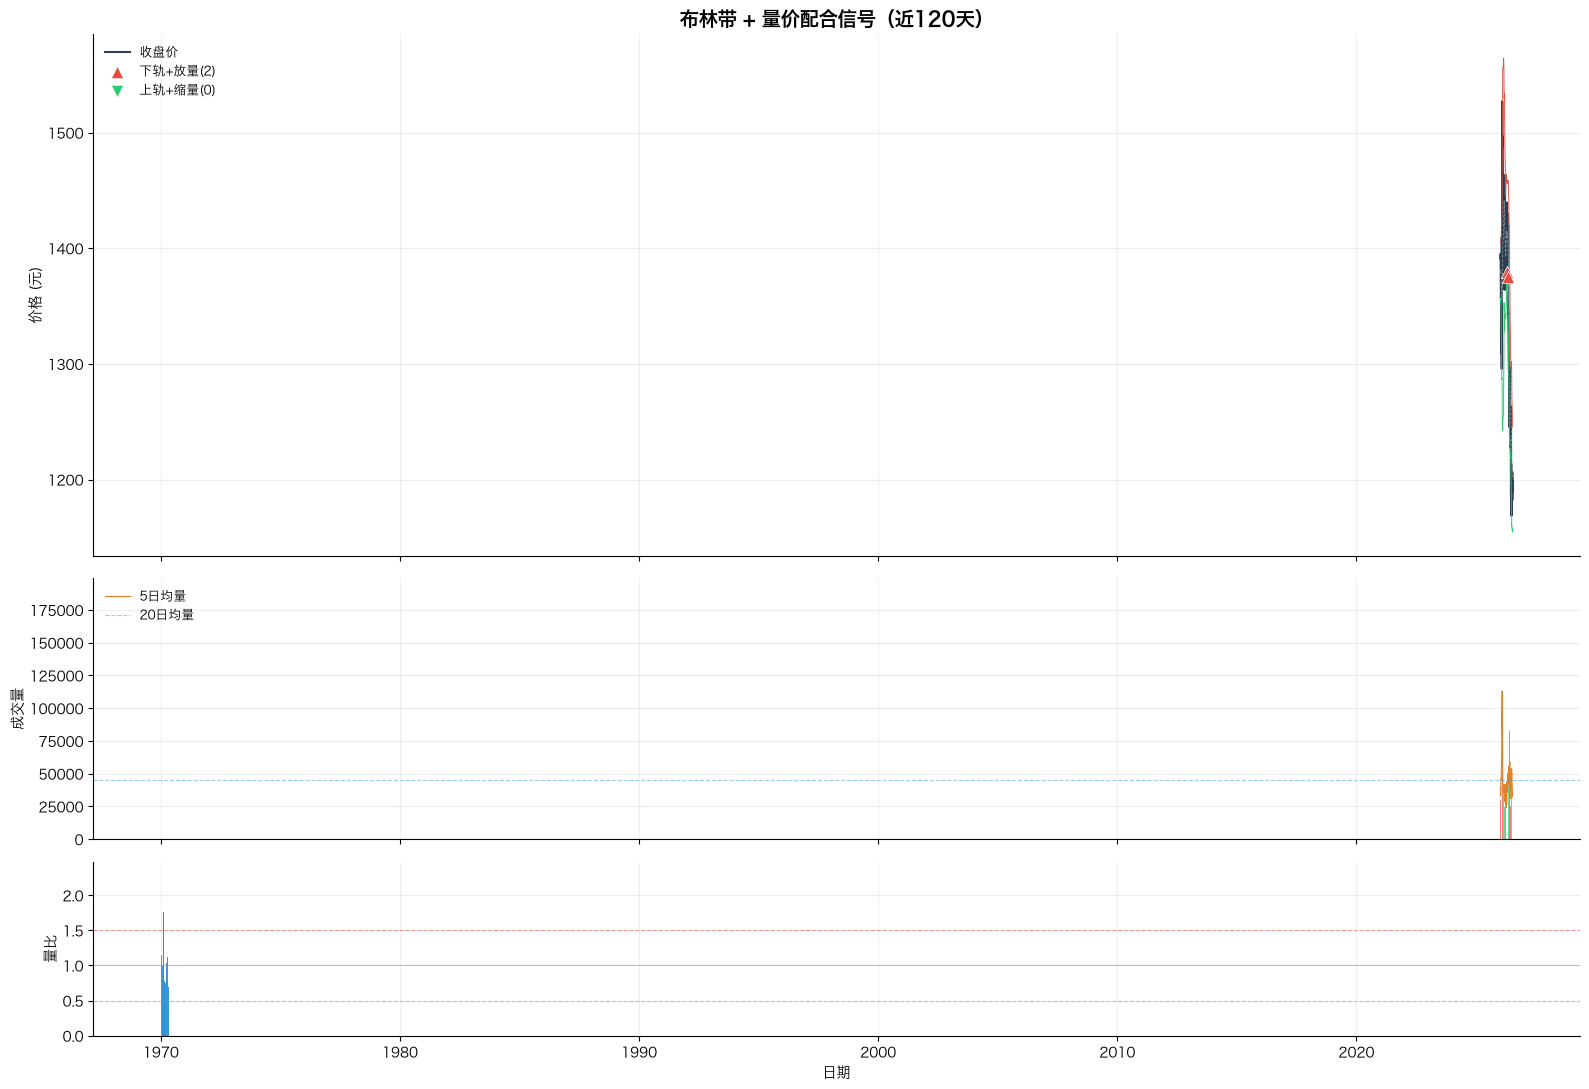

In [11]:
# ===== 综合可视化：量价+布林带 =====

d = df.iloc[-120:]

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 11),
                                     gridspec_kw={'height_ratios': [3, 1.5, 1]}, sharex=True)

# 图1: 价格 + 布林带 + 信号标记
ax1.fill_between(d.index, d['BB_Up'], d['BB_Lo'], alpha=0.08, color='#3498db')
ax1.plot(d.index, d['收盘'], color='#2c3e50', lw=1.5, label='收盘价')
ax1.plot(d.index, d['BB_Up'], color='#e74c3c', lw=0.6)
ax1.plot(d.index, d['BB_Mid'], color='#7f8c8d', lw=0.6, ls='--')
ax1.plot(d.index, d['BB_Lo'], color='#2ecc71', lw=0.6)

# 标记碰下轨放量（买入信号）
buy_signals = d[(d['碰下轨']) & (d['放量'])]
ax1.scatter(buy_signals.index, buy_signals['收盘'], color='#e74c3c', s=80, zorder=5,
            marker='^', edgecolor='white', lw=0.5, label=f'下轨+放量({len(buy_signals)})')

# 标记碰上轨缩量（卖出信号）
sell_signals = d[(d['碰上轨']) & (d['缩量'])]
ax1.scatter(sell_signals.index, sell_signals['收盘'], color='#2ecc71', s=80, zorder=5,
            marker='v', edgecolor='white', lw=0.5, label=f'上轨+缩量({len(sell_signals)})')

ax1.set_title('布林带 + 量价配合信号（近120天）', fontsize=14, fontweight='bold')
ax1.set_ylabel('价格 (元)')
ax1.legend(loc='upper left', frameon=False, fontsize=9)

# 图2: 成交量 + 量比
up_mask = d['收盘'] >= d['开盘']
ax2.bar(d.index[up_mask], d['成交量'][up_mask], color='#e74c3c', width=1, alpha=0.7)
ax2.bar(d.index[~up_mask], d['成交量'][~up_mask], color='#2ecc71', width=1, alpha=0.7)
ax2.plot(d.index, d['Vol_MA5'], color='#e67e22', lw=0.8, label='5日均量')
ax2.axhline(d['Vol_MA20'].iloc[-1], color='#3498db', lw=0.8, ls='--', alpha=0.5, label='20日均量')
ax2.set_ylabel('成交量')
ax2.legend(loc='upper left', frameon=False, fontsize=9)

# 图3: 量比
colors = ['#e74c3c' if v > 1.5 else ('#2ecc71' if v < 0.5 else '#3498db') for v in d['量比']]
ax3.bar(range(len(d)), d['量比'], color=colors, width=1)
ax3.axhline(1.5, color='#e74c3c', lw=0.8, ls='--', alpha=0.5)
ax3.axhline(1.0, color='#7f8c8d', lw=0.8, alpha=0.5)
ax3.axhline(0.5, color='#2ecc71', lw=0.8, ls='--', alpha=0.5)
ax3.set_ylabel('量比')
ax3.set_xlabel('日期')

for ax in [ax1, ax2, ax3]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

In [12]:
# ===== 三只股票布林带对比 =====

stocks_info = [('茅台', '../data/茅台.csv'), ('招商银行', '../data/招商银行.csv'),
               ('比亚迪', '../data/比亚迪.csv')]

print('三只股票布林带现状对比:')
print('=' * 70)
print(f'{"股票":<8} {"收盘价":>8} {"中轨":>8} {"上轨":>8} {"下轨":>8} {"%B":>7} {"带宽":>7}')
print('-' * 55)

for name, path in stocks_info:
    s = pd.read_csv(path)
    s['日期'] = pd.to_datetime(s['日期'])
    s = s.set_index('日期').sort_index()

    bb_mid = s['收盘'].rolling(20).mean()
    bb_std = s['收盘'].rolling(20).std(ddof=0)
    bb_up = bb_mid + 2 * bb_std
    bb_lo = bb_mid - 2 * bb_std
    bb_b = (s['收盘'] - bb_lo) / (bb_up - bb_lo)
    bb_bw = (bb_up - bb_lo) / bb_mid

    print(f'{name:<8} {s["收盘"].iloc[-1]:>8.2f} {bb_mid.iloc[-1]:>8.2f} '
          f'{bb_up.iloc[-1]:>8.2f} {bb_lo.iloc[-1]:>8.2f} '
          f'{bb_b.iloc[-1]:>7.3f} {bb_bw.iloc[-1]*100:>6.1f}%')

print('\n解读:')
print('  %B > 0.8 → 价格在轨道上方（超强或即将回落）')
print('  %B < 0.2 → 价格在轨道下方（超弱或即将反弹）')
print('  带宽大 → 波动率高，趋势行情中')
print('  带宽小 → 波动率低，盘整中，随时可能突破')

三只股票布林带现状对比:
股票            收盘价       中轨       上轨       下轨      %B      带宽
-------------------------------------------------------
茅台        1204.98  1201.34  1245.35  1157.34   0.541    7.3%
招商银行        36.88    36.32    38.33    34.30   0.640   11.1%
比亚迪         90.00    85.72    93.50    77.95   0.775   18.1%

解读:
  %B > 0.8 → 价格在轨道上方（超强或即将回落）
  %B < 0.2 → 价格在轨道下方（超弱或即将反弹）
  带宽大 → 波动率高，趋势行情中
  带宽小 → 波动率低，盘整中，随时可能突破


## 📝 今天的发现

运行完上面的分析后，回答这三个问题（写进 `day18/学习笔记.txt`）：

1. 茅台的布林带 %B 当前是多少？价格在轨道的什么位置？
2. 量价四象限中，哪种组合之后上涨概率最大？哪种最危险？
3. 布林带和均线（MA）有什么本质区别？什么时候用布林带、什么时候用均线？